# 09. Social Security Funds mechanisms

Analyse Social Security Funds revenue composition in national accounts, and the CFP internal budget systems separately, without merging two incompatible accounting boundaries.

**Reads**

- `outputs/tables/social_security_account_metrics.csv`
- `outputs/tables/social_security_system_metrics_2019_2025.csv`
- `outputs/tables/social_security_detail_metrics_2024_2025.csv`

**Writes**

- Nothing. All three tables are persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 10

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. National-accounts view

This is the ESA 2010 Social Security Funds sector, the same entity that appears
in the B.9 identity. Social contributions are the dominant revenue item, and the
contribution share is the composition metric used later in the report.

In [2]:
ssf = pd.read_csv(TABLES / 'social_security_account_metrics.csv')
account_columns = [
    'year',
    'total_revenue_m_eur',
    'social_contributions_m_eur',
    'contributions_share_total_revenue',
    'total_expenditure_m_eur',
    'balance_m_eur',
]
display(ssf[account_columns].tail(12).round(3))

,year,total_revenue_m_eur,social_contributions_m_eur,contributions_share_total_revenue,total_expenditure_m_eur,balance_m_eur
33,2014,23744.982,13546.404,0.570,22937.346,807.636
34,2015,24091.596,14131.051,0.587,22963.062,1128.534
35,2016,24800.032,14841.064,0.598,23230.089,1569.943
36,2017,25876.981,15883.272,0.614,23634.427,2242.554
37,2018,26675.139,17049.069,0.639,24640.347,2034.792
38,2019,28812.083,18532.578,0.643,25836.613,2975.470
39,2020,31320.770,18844.001,0.602,29122.861,2197.909
40,2021,32296.492,20273.610,0.628,29828.175,2468.317
41,2022,34723.692,22563.085,0.650,30424.288,4299.404
42,2023,37866.691,25368.629,0.670,32146.532,5720.159


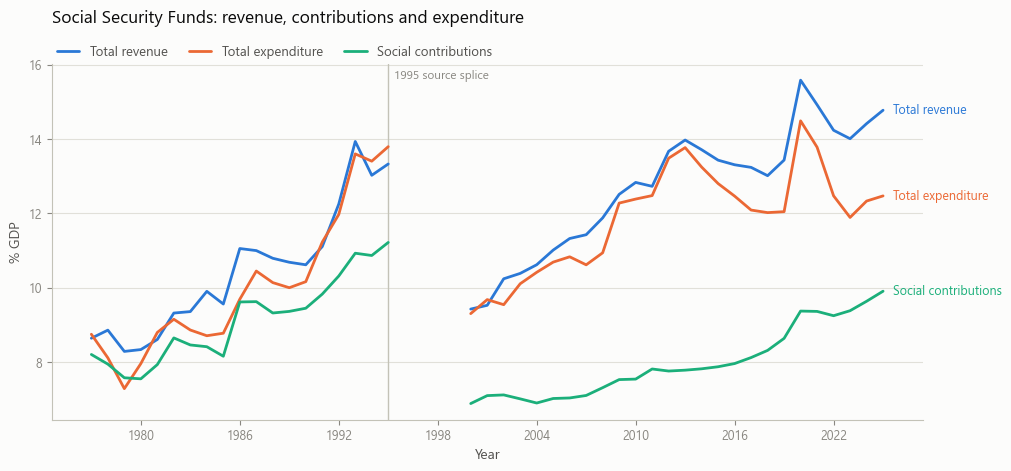

In [3]:
figure = figures.social_security_composition(ssf)

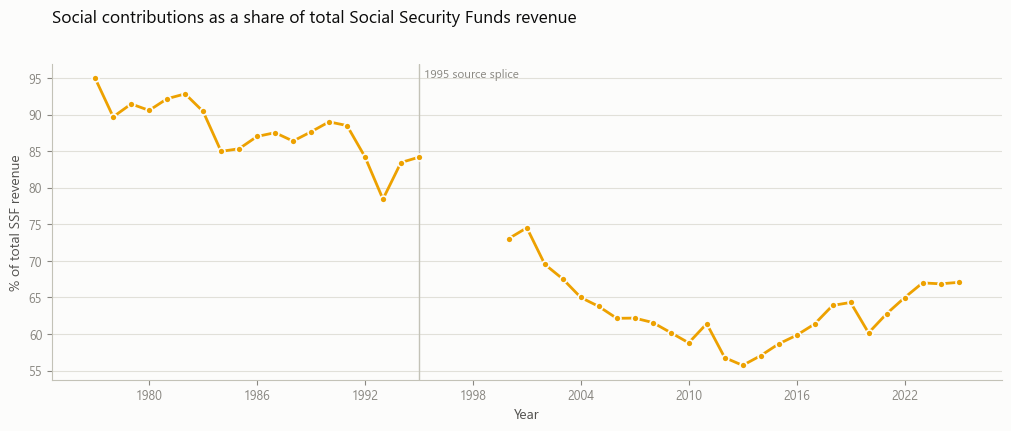

In [4]:
figure = figures.social_security_contribution_share(ssf)

## 2. A different boundary: the CFP budget systems

The CFP Social Security report decomposes the system into the Previdential
system, the Social Protection of Citizenship system and special regimes. These
are **budget-execution** aggregates. They are not a partition of the ESA 2010
Social Security Funds balance and are never added to it.

In [5]:
systems = pd.read_csv(TABLES / 'social_security_system_metrics_2019_2025.csv')
detail = pd.read_csv(TABLES / 'social_security_detail_metrics_2024_2025.csv')
display(systems.round(1))
display(detail.set_index('year').T)

,year,citizenship_system_balance_m_eur,previdential_system_balance_m_eur,special_regimes_balance_m_eur,source,system_sum_m_eur
0,2019,443,2333,0,CFP Social Security 2025 report underlying data,2776
1,2020,423,1649,0,CFP Social Security 2025 report underlying data,2072
2,2021,653,1695,0,CFP Social Security 2025 report underlying data,2348
3,2022,-110,4172,0,CFP Social Security 2025 report underlying data,4062
4,2023,1,5485,0,CFP Social Security 2025 report underlying data,5486
5,2024,-245,5840,0,CFP Social Security 2025 report underlying data,5595
6,2025,-55,6712,0,CFP Social Security 2025 report underlying data,6657


year,2024,2025
social_contributions_m_eur,27688,30152
state_budget_transfers_m_eur,9199,9956
state_budget_lbss_transfers_m_eur,8620,9442
rsi_expenditure_m_eur,358,342
professional_training_subsidies_m_eur,41,96
social_security_budget_balance_m_eur,5591,6672
previdential_revenue_m_eur,30107,32679
previdential_contributions_m_eur,27688,30152
previdential_state_transfers_m_eur,322,317
previdential_training_employment_expenditure_m_eur,950,1031


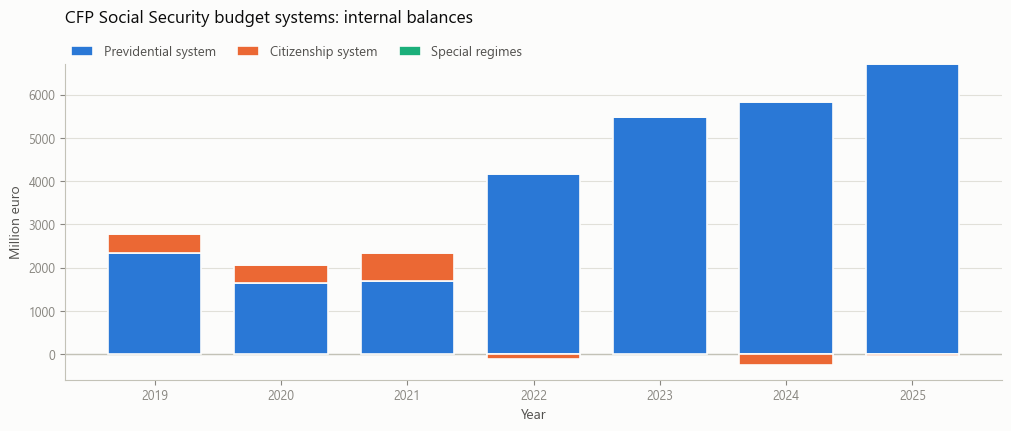

In [6]:
figure = figures.social_security_systems(systems)

## Interpretation limits

1. The two layers in this notebook have **different accounting boundaries** and
   are reported side by side, never combined.
2. The repository does **not** subtract State transfers from the Social Security
   balance and call the remainder an underlying balance. Which transfers finance
   which statutory responsibility is a legal question, not an accounting one.
3. The contribution share is a **composition ratio**. It says nothing about the
   adequacy or sustainability of the system.
4. Internal system tables cover **2019-2025 only**, with detail for 2024-2025.

---

[Previous: 08. Structural mean shifts](08_structural_breaks.ipynb) | [Next: 10. Intergovernmental transfer sensitivity](10_intergovernmental_transfers.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```